In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
logs = pd.read_csv('../results/babilong_new.csv')
logs.head()

,from_pretrained,model_cfg,model_cls,model_type,lr,batch_size,lr_scheduler,max_n_segments,num_mem_tokens,model_path,num_steps,best_valid_exact_match,exact_match,k2,freeze_model_weights
0,gpt2,NaN,modeling_rmt.block_resrmt:GPT2ModelWithBlockWi...,decoder,0.00001,1,linear,6,16,/data/home/admin/rmt/runs/qa1_single-supportin...,700,1.0,1.0,-1,False
1,gpt2,NaN,modeling_rmt.block_resrmt:GPT2ModelWithBlockWi...,decoder,0.00001,1,linear,6,2,/data/home/admin/rmt/runs/qa1_single-supportin...,1000,1.0,1.0,-1,False
2,gpt2,NaN,modeling_rmt.block_resrmt:GPT2ModelWithBlockWi...,decoder,0.00001,1,linear,6,4,/data/home/admin/rmt/runs/qa1_single-supportin...,1000,1.0,1.0,-1,False
3,gpt2,NaN,modeling_rmt.block_resrmt:GPT2ModelWithBlockWi...,decoder,0.00001,1,linear,6,1,/data/home/admin/rmt/runs/qa1_single-supportin...,1400,1.0,1.0,-1,False
4,gpt2,NaN,modeling_rmt.block_resrmt:GPT2ModelWithBlockWi...,decoder,0.00001,1,linear,6,4,/data/home/admin/rmt/runs/qa1_single-supportin...,1000,1.0,1.0,-1,False


In [5]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tensorboard_scalars(logdir, tag):
    event_acc = EventAccumulator(logdir)
    event_acc.Reload()
    if tag in event_acc.Tags()["scalars"]:
        return [(scalar.step, scalar.value) for scalar in event_acc.Scalars(tag)]
    else:
        print(f"Tag '{tag}' not found in logs.")
        return []

runs = ['rmt_base', 'br_base']
tags = ['exact_match/iterations/train', 'exact_match/iterations/valid']
run_acc = {}
max_len = {tag: 0 for tag in tags}

for run in runs:
    logdirs = logs[logs['model_path'].str.contains(run)]['model_path'].tolist()
    for logdir in logdirs:
        run_name = logdir.split('/')[-1]
        run_acc[run_name] = {}
        for tag in tags:
            run_acc[run_name][tag] = list(list(l) for l in zip(*load_tensorboard_scalars(logdir, tag)))
            max_len[tag] = max(max_len[tag], len(run_acc[run_name][tag][0]))

In [6]:
import numpy as np


for run, t in run_acc.items():
    for tag, v in t.items():
        vv = np.array(v)
        padded_run = np.full((2, max_len[tag]), np.nan)
        padded_run[:, :vv.shape[1]] = vv
        run_acc[run][tag] = padded_run

run_acc

{'run_rmt_base1': {'exact_match/iterations/train': array([[ 0., 25., 50., ..., nan, nan, nan],
         [ 0.,  0.,  0., ..., nan, nan, nan]], shape=(2, 1112)),
  'exact_match/iterations/valid': array([[0.00000000e+00, 1.00000000e+02, 2.00000000e+02, 3.00000000e+02,
          4.00000000e+02, 5.00000000e+02, 6.00000000e+02, 7.00000000e+02,
          8.00000000e+02, 9.00000000e+02, 1.00000000e+03, 1.10000000e+03,
          1.20000000e+03, 1.30000000e+03, 1.40000000e+03, 1.50000000e+03,
          1.60000000e+03, 1.70000000e+03, 1.80000000e+03, 1.90000000e+03,
          2.00000000e+03, 2.10000000e+03, 2.20000000e+03, 2.30000000e+03,
          2.40000000e+03, 2.50000000e+03, 2.60000000e+03, 2.70000000e+03,
          2.80000000e+03, 2.90000000e+03, 3.00000000e+03, 3.10000000e+03,
          3.20000000e+03, 3.30000000e+03, 3.40000000e+03, 3.50000000e+03,
          3.60000000e+03, 3.70000000e+03, 3.80000000e+03, 3.90000000e+03,
          4.00000000e+03, 4.10000000e+03, 4.20000000e+03, 4.30000000

In [7]:
means, stds = {}, {}

for run in runs:
    means[run] = {}
    stds[run] = {}
    for tag in tags:
        needed_runs = [r for r in run_acc if run in r]
        vals = np.array([run_acc[r][tag][1, :] for r in needed_runs])
        means[run][tag] = np.nanmean(vals, axis=0)
        stds[run][tag] = np.nanstd(vals, axis=0)
means

/tmp/ipykernel_20460/1889067388.py:9: RuntimeWarning: Mean of empty slice
  means[run][tag] = np.nanmean(vals, axis=0)
/data/home/admin/miniforge3/envs/rmt/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


{'rmt_base': {'exact_match/iterations/train': array([ 0.,  0.,  0., ..., nan, nan, nan], shape=(1112,)),
  'exact_match/iterations/valid': array([0.        , 0.        , 0.        , 0.        , 0.        ,
         0.11861861, 0.18318318, 0.1991992 , 0.22172172, 0.3093093 ,
         0.37637639, 0.3928929 , 0.3968969 , 0.4104104 , 0.42392392,
         0.42342342, 0.4104104 , 0.41641641, 0.42192192, 0.42292292,
         0.43143144, 0.42542543, 0.44694695, 0.44894895, 0.46496496,
         0.46246246, 0.53753754, 0.64864865, 0.72172174, 0.74674675,
         0.77877879, 0.77877879, 0.77177176, 0.7907908 , 0.7932933 ,
         0.7982983 , 0.8003003 , 0.8013013 , 0.8018018 , 0.7997998 ,
         0.8038038 , 0.7902903 , 0.8003003 , 0.7967968 , 0.77777779,
         0.8018018 , 0.7942943 , 0.7987988 , 0.8023023 , 0.8028028 ,
         0.8023023 , 0.8073073 , 0.8118118 , 0.83333331, 0.82232231,
         0.83883885, 0.86436439, 0.87887889, 0.88188189, 0.86336336,
         0.88488489, 0.8963964 , 0.

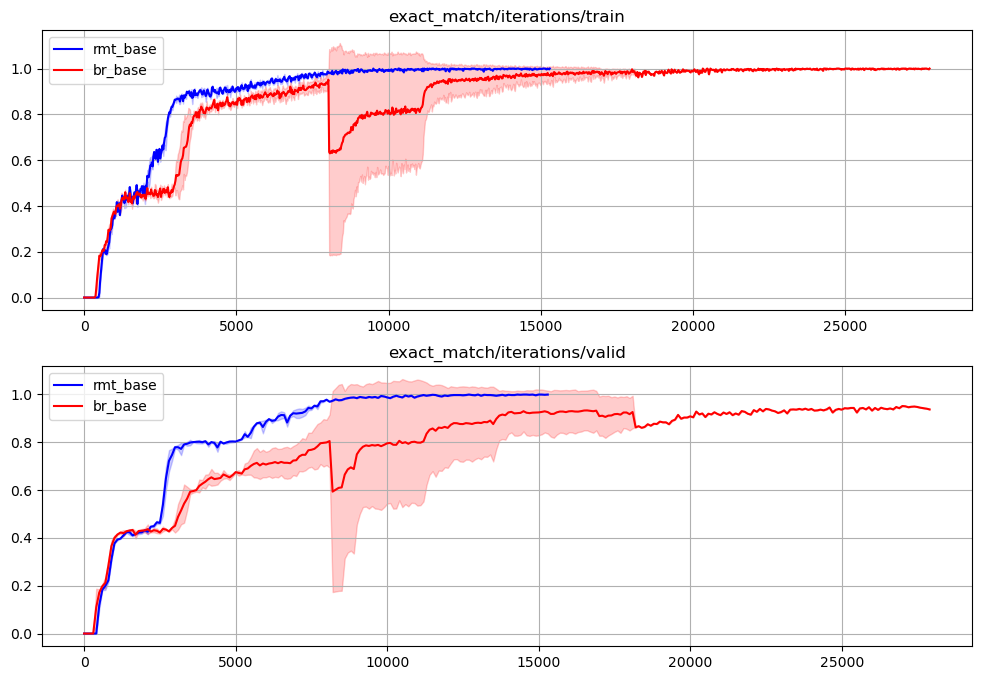

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
steps = {
    'exact_match/iterations/train': np.arange(max_len['exact_match/iterations/train']) * 25,
    'exact_match/iterations/valid': np.arange(max_len['exact_match/iterations/valid']) * 100
}
col = ['b', 'r']

for i, tag in enumerate(tags):
    ax[i].set_title(tag)
    ax[i].grid()
    for run, c in zip(runs, col):
        ax[i].plot(steps[tag], means[run][tag], label=run, color=c)
        ax[i].fill_between(steps[tag], means[run][tag] - stds[run][tag], means[run][tag] + stds[run][tag], alpha=0.2, color=c)
    ax[i].legend()
        
plt.show()